In [1]:
import pandas as pd

DATA_PATH = "/kaggle/input/datasets/aqdam7/mall-customer-dataset/Mall_Customers.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)

(200, 5)


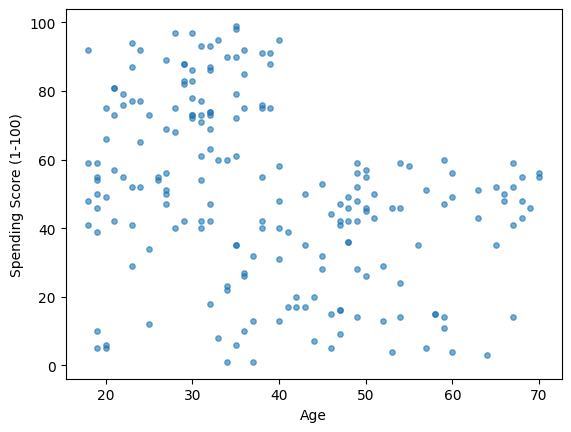

In [2]:
import matplotlib.pyplot as plt

plt.scatter(
    df["Age"],
    df["Spending Score (1-100)"],
    s=15,
    alpha=0.6
)

plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.show()

In [7]:
from sklearn.preprocessing import StandardScaler

X = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].values

X_scaled = StandardScaler().fit_transform(X)

In [8]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

kmeans.fit(X_scaled)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [9]:
df["Cluster"] = kmeans.predict(X_scaled)

print(df["Cluster"].value_counts())

Cluster
1    54
4    47
2    40
3    39
0    20
Name: count, dtype: int64


In [10]:
from sklearn.metrics import silhouette_score

print(silhouette_score(X_scaled, df["Cluster"]))

print(
    df.groupby("Cluster")[
        ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
    ].mean()
)

0.41664341513732767
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        46.250000           26.750000               18.350000
1        25.185185           41.092593               62.240741
2        32.875000           86.100000               81.525000
3        39.871795           86.102564               19.358974
4        55.638298           54.382979               48.851064
